# QQQ Drawdown Detection - Model Training and Evaluation
------------------------------------------

### Import the modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)

print('Modules are imported.')

Modules are imported.


### Load the labeled dataset

In [2]:
print("="*60)
print("CARGANDO DATOS")
print("="*60)

df = pd.read_csv('Data/QQQ_features_with_drawdowns.csv', index_col=0, parse_dates=True)

print(f"✅ Datos cargados: {len(df)} registros")
print(f"   Período: {df.index[0].date()} a {df.index[-1].date()}")

CARGANDO DATOS
✅ Datos cargados: 2568 registros
   Período: 2014-10-16 a 2024-12-30


### Define features and target

In [3]:
print("\n" + "="*60)
print("PREPARANDO DATOS PARA ML")
print("="*60 + "\n")

# Features para el modelo
feature_columns = [
    'VIX', 'RSI_14d', 'MACD', 'Historical_Vol_30d',
    'Bollinger_Band_Width', 'ATR_14d', 'Distance_to_MA200',
    'Volume_Ratio', 'SPY_QQQ_Correlation', 'Return_20d'
]

# Target
target_column = 'Drawdown_30d'

print(f"📊 Features seleccionados: {len(feature_columns)}")
for feature in feature_columns:
    print(f"   - {feature}")
print(f"\n🎯 Target: {target_column}")


PREPARANDO DATOS PARA ML

📊 Features seleccionados: 10
   - VIX
   - RSI_14d
   - MACD
   - Historical_Vol_30d
   - Bollinger_Band_Width
   - ATR_14d
   - Distance_to_MA200
   - Volume_Ratio
   - SPY_QQQ_Correlation
   - Return_20d

🎯 Target: Drawdown_30d


### Check for missing values

In [4]:
# Verificar valores faltantes
print(f"\n🧹 Registros antes de limpiar NaN: {len(df)}")

df_clean = df[feature_columns + [target_column]].dropna()

print(f"✅ Registros después de limpiar NaN: {len(df_clean)}")
print(f"   Registros eliminados: {len(df) - len(df_clean)}")


🧹 Registros antes de limpiar NaN: 2568
✅ Registros después de limpiar NaN: 2568
   Registros eliminados: 0


### Check class balance

In [5]:
# Balance de clases
class_counts = df_clean[target_column].value_counts()
class_pcts = df_clean[target_column].value_counts(normalize=True) * 100

print(f"\n⚖️  Balance de clases:")
print(f"   Clase 0 (Normal): {class_counts[0]} ({class_pcts[0]:.2f}%)")
print(f"   Clase 1 (Drawdown): {class_counts[1]} ({class_pcts[1]:.2f}%)")


⚖️  Balance de clases:
   Clase 0 (Normal): 2056 (80.06%)
   Clase 1 (Drawdown): 512 (19.94%)


### Split data temporally (Train/Test)

In [6]:
print("\n" + "="*60)
print("DIVISIÓN TRAIN/TEST TEMPORAL")
print("="*60 + "\n")

# División temporal (no aleatoria, respetando la cronología)
split_date = '2021-01-01'
train_data = df_clean[df_clean.index < split_date]
test_data = df_clean[df_clean.index >= split_date]

print(f"📅 Fecha de corte: {split_date}\n")

# Separar features y target
X_train = train_data[feature_columns]
y_train = train_data[target_column]
X_test = test_data[feature_columns]
y_test = test_data[target_column]

# Estadísticas
print(f"🔵 Training set:")
print(f"   Período: {train_data.index[0].date()} a {train_data.index[-1].date()}")
print(f"   Registros: {len(X_train)} ({len(X_train)/len(df_clean)*100:.1f}%)")
print(f"   Drawdowns: {y_train.sum()} ({y_train.sum()/len(y_train)*100:.2f}%)")

print(f"\n🔴 Test set:")
print(f"   Período: {test_data.index[0].date()} a {test_data.index[-1].date()}")
print(f"   Registros: {len(X_test)} ({len(X_test)/len(df_clean)*100:.1f}%)")
print(f"   Drawdowns: {y_test.sum()} ({y_test.sum()/len(y_test)*100:.2f}%)")

print(f"\n📊 Shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   X_test: {X_test.shape}")
print(f"   y_test: {y_test.shape}")


DIVISIÓN TRAIN/TEST TEMPORAL

📅 Fecha de corte: 2021-01-01

🔵 Training set:
   Período: 2014-10-16 a 2020-12-31
   Registros: 1564 (60.9%)
   Drawdowns: 142 (9.08%)

🔴 Test set:
   Período: 2021-01-04 a 2024-12-30
   Registros: 1004 (39.1%)
   Drawdowns: 370 (36.85%)

📊 Shapes:
   X_train: (1564, 10)
   y_train: (1564,)
   X_test: (1004, 10)
   y_test: (1004,)


### Train Random Forest Model

In [7]:
print("\n" + "="*60)
print("ENTRENANDO RANDOM FOREST")
print("="*60 + "\n")

# Configuración del modelo
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',  # Para manejar desbalance de clases
    random_state=42,
    n_jobs=-1,
    verbose=1
)

print(f"🌲 Configuración del modelo:")
print(f"   - n_estimators: {rf_model.n_estimators}")
print(f"   - max_depth: {rf_model.max_depth}")
print(f"   - class_weight: {rf_model.class_weight}")
print(f"   - random_state: {rf_model.random_state}")

print(f"\n⏳ Entrenando modelo...")
rf_model.fit(X_train, y_train)
print(f"✅ Modelo entrenado exitosamente!")


ENTRENANDO RANDOM FOREST

🌲 Configuración del modelo:
   - n_estimators: 100
   - max_depth: 10
   - class_weight: balanced
   - random_state: 42

⏳ Entrenando modelo...
✅ Modelo entrenado exitosamente!


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.0s finished


### Generate predictions

In [8]:
print("\n" + "="*60)
print("GENERANDO PREDICCIONES")
print("="*60)

# Predicciones
y_train_pred = rf_model.predict(X_train)
y_test_pred = rf_model.predict(X_test)

# Probabilidades
y_train_proba = rf_model.predict_proba(X_train)[:, 1]
y_test_proba = rf_model.predict_proba(X_test)[:, 1]

print(f"✅ Predicciones generadas")
print(f"   Training: {len(y_train_pred)} predicciones")
print(f"   Test: {len(y_test_pred)} predicciones")


GENERANDO PREDICCIONES


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


✅ Predicciones generadas
   Training: 1564 predicciones
   Test: 1004 predicciones


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 100 out of 100 | elapsed:    0.0s finished


### Evaluate model - Training metrics

In [9]:
print("\n" + "="*60)
print("MÉTRICAS DE EVALUACIÓN")
print("="*60 + "\n")

# Métricas Training
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred)
train_recall = recall_score(y_train, y_train_pred)
train_f1 = f1_score(y_train, y_train_pred)
train_roc_auc = roc_auc_score(y_train, y_train_proba)

print(f"🔵 TRAINING SET:")
print(f"   Accuracy: {train_accuracy:.4f}")
print(f"   Precision: {train_precision:.4f}")
print(f"   Recall: {train_recall:.4f}")
print(f"   F1-Score: {train_f1:.4f}")
print(f"   ROC-AUC: {train_roc_auc:.4f}")


MÉTRICAS DE EVALUACIÓN

🔵 TRAINING SET:
   Accuracy: 1.0000
   Precision: 1.0000
   Recall: 1.0000
   F1-Score: 1.0000
   ROC-AUC: 1.0000


### Evaluate model - Test metrics

In [10]:
# Métricas Test
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred)
test_recall = recall_score(y_test, y_test_pred)
test_f1 = f1_score(y_test, y_test_pred)
test_roc_auc = roc_auc_score(y_test, y_test_proba)

print(f"\n🔴 TEST SET:")
print(f"   Accuracy: {test_accuracy:.4f}")
print(f"   Precision: {test_precision:.4f}")
print(f"   Recall: {test_recall:.4f}")
print(f"   F1-Score: {test_f1:.4f}")
print(f"   ROC-AUC: {test_roc_auc:.4f}")


🔴 TEST SET:
   Accuracy: 0.8516
   Precision: 0.9911
   Recall: 0.6027
   F1-Score: 0.7496
   ROC-AUC: 0.8760


### Classification Report (Test Set)

In [11]:
# Classification Report
print(f"\n📊 CLASSIFICATION REPORT (Test Set):")
print(classification_report(y_test, y_test_pred, target_names=['Normal', 'Drawdown']))


📊 CLASSIFICATION REPORT (Test Set):
              precision    recall  f1-score   support

      Normal       0.81      1.00      0.89       634
    Drawdown       0.99      0.60      0.75       370

    accuracy                           0.85      1004
   macro avg       0.90      0.80      0.82      1004
weighted avg       0.88      0.85      0.84      1004



### Confusion Matrix (Test Set)

In [12]:
# Matriz de Confusión
cm = confusion_matrix(y_test, y_test_pred)

print(f"\n🔢 MATRIZ DE CONFUSIÓN (Test Set):")
print(cm)
print(f"\n   TN: {cm[0,0]}, FP: {cm[0,1]}")
print(f"   FN: {cm[1,0]}, TP: {cm[1,1]}")


🔢 MATRIZ DE CONFUSIÓN (Test Set):
[[632   2]
 [147 223]]

   TN: 632, FP: 2
   FN: 147, TP: 223


### Feature Importance Analysis

In [13]:
print("\n" + "="*60)
print("IMPORTANCIA DE FEATURES")
print("="*60)

# Obtener importancia de features
feature_importance = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print(f"\n🏆 Top 10 Features más importantes:")
print(feature_importance.to_string(index=False))


IMPORTANCIA DE FEATURES

🏆 Top 10 Features más importantes:
             Feature  Importance
  Historical_Vol_30d    0.247465
   Distance_to_MA200    0.178133
                 VIX    0.173588
                MACD    0.106919
Bollinger_Band_Width    0.102437
             ATR_14d    0.072885
             RSI_14d    0.052724
          Return_20d    0.031864
 SPY_QQQ_Correlation    0.020643
        Volume_Ratio    0.013344


### Save trained model

In [14]:
print("\n" + "="*60)
print("GUARDANDO MODELO")
print("="*60)

# Guardar modelo entrenado
model_filename = 'Models/random_forest_qqq_drawdown.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(rf_model, file)
print(f"✅ Modelo guardado: {model_filename}")


GUARDANDO MODELO
✅ Modelo guardado: Models/random_forest_qqq_drawdown.pkl


### Save model information

In [15]:
# Guardar información adicional
model_info = {
    'feature_columns': feature_columns,
    'target_column': target_column,
    'split_date': split_date,
    'train_period': f"{train_data.index[0].date()} a {train_data.index[-1].date()}",
    'test_period': f"{test_data.index[0].date()} a {test_data.index[-1].date()}",
    'train_size': len(X_train),
    'test_size': len(X_test),
    'test_accuracy': test_accuracy,
    'test_f1': test_f1,
    'feature_importance': feature_importance.to_dict()
}

info_filename = 'Models/model_info.pkl'
with open(info_filename, 'wb') as file:
    pickle.dump(model_info, file)
print(f"✅ Información del modelo guardada: {info_filename}")

✅ Información del modelo guardada: Models/model_info.pkl


### Visualization 1: Feature Importance


GENERANDO VISUALIZACIONES
📊 Gráfico guardado: feature_importance.png


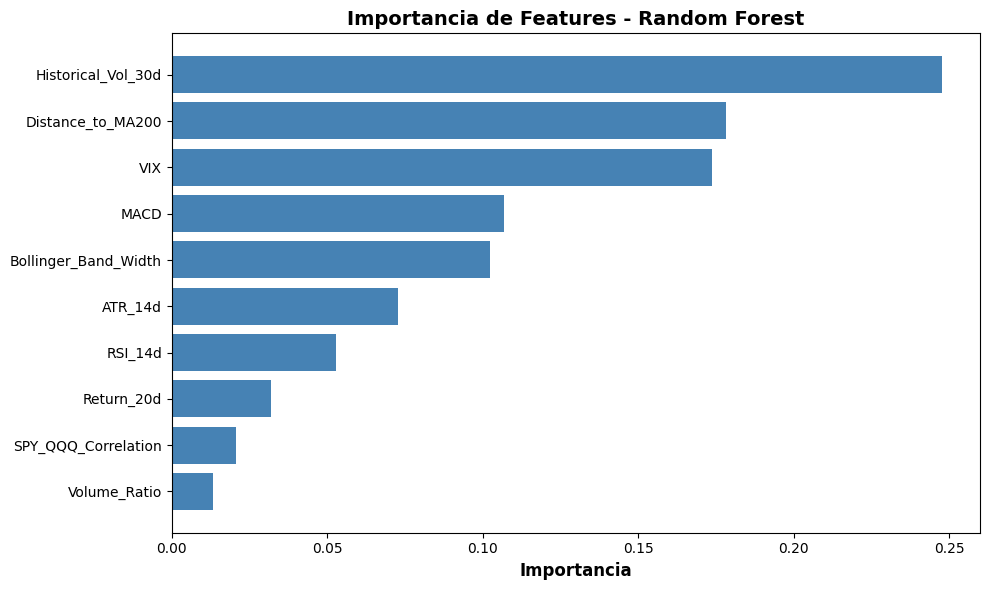

In [16]:
print("\n" + "="*60)
print("GENERANDO VISUALIZACIONES")
print("="*60)

# Feature Importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importancia', fontsize=12, fontweight='bold')
plt.title('Importancia de Features - Random Forest', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: feature_importance.png")
plt.show()

### Visualization 2: Confusion Matrices (Train vs Test)

📊 Gráfico guardado: confusion_matrices.png


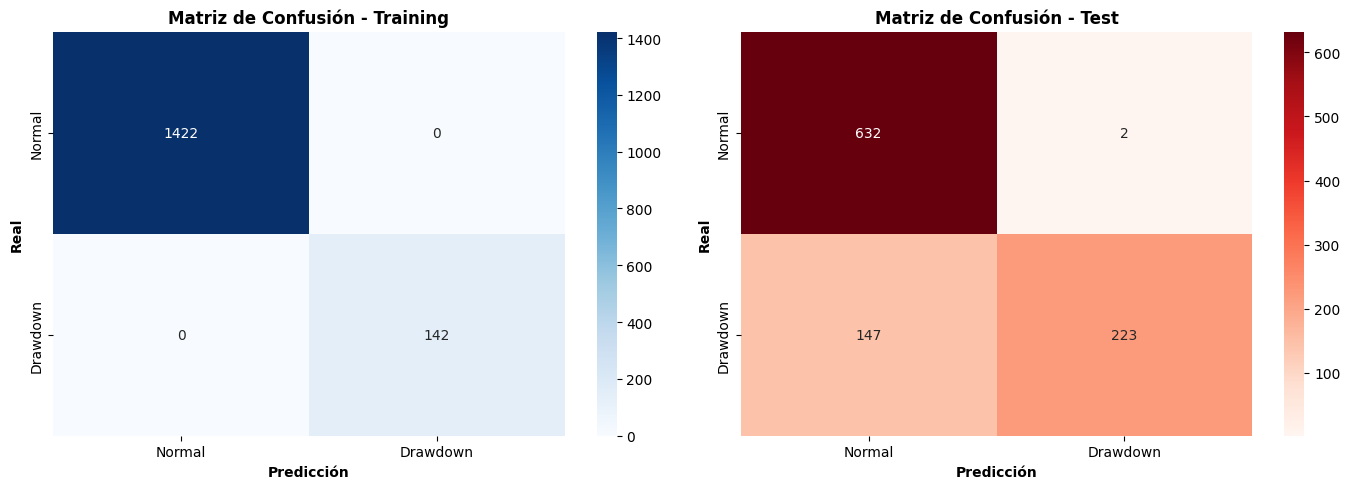

In [17]:
# Matriz de Confusión
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Training
cm_train = confusion_matrix(y_train, y_train_pred)
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues', ax=ax1, 
            xticklabels=['Normal', 'Drawdown'], yticklabels=['Normal', 'Drawdown'])
ax1.set_title('Matriz de Confusión - Training', fontsize=12, fontweight='bold')
ax1.set_ylabel('Real', fontsize=10, fontweight='bold')
ax1.set_xlabel('Predicción', fontsize=10, fontweight='bold')

# Test
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds', ax=ax2,
            xticklabels=['Normal', 'Drawdown'], yticklabels=['Normal', 'Drawdown'])
ax2.set_title('Matriz de Confusión - Test', fontsize=12, fontweight='bold')
ax2.set_ylabel('Real', fontsize=10, fontweight='bold')
ax2.set_xlabel('Predicción', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=300, bbox_inches='tight')
print("📊 Gráfico guardado: confusion_matrices.png")
plt.show()

### Visualization 3: ROC Curve

📊 Gráfico guardado: roc_curve.png


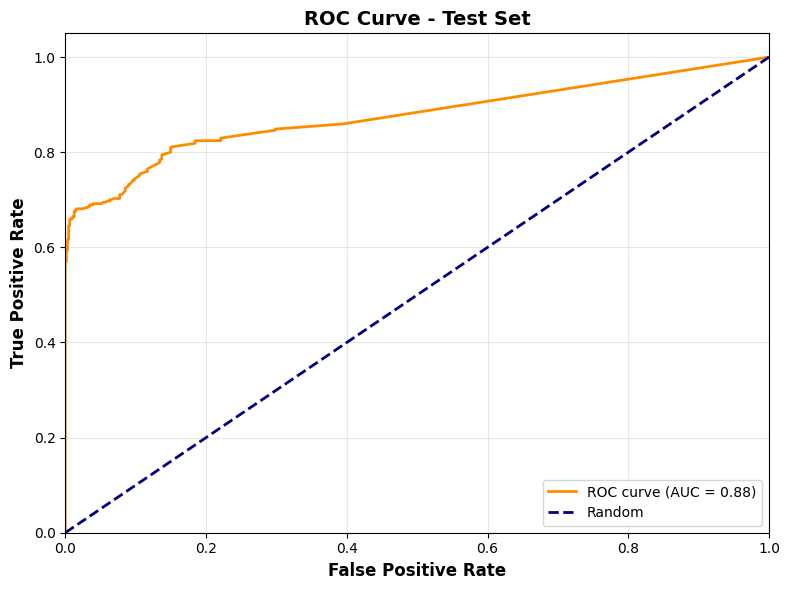

In [18]:
# ROC Curve
try:
    fpr, tpr, thresholds = roc_curve(y_test, y_test_proba)
    roc_auc = roc_auc_score(y_test, y_test_proba)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=12, fontweight='bold')
    plt.title('ROC Curve - Test Set', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('roc_curve.png', dpi=300, bbox_inches='tight')
    print("📊 Gráfico guardado: roc_curve.png")
    plt.show()
except Exception as e:
    print(f"⚠️  No se pudo generar ROC curve: {e}")

### Save test predictions

In [19]:
# Guardar predicciones del test set con fechas
predictions_df = pd.DataFrame({
    'Date': test_data.index,
    'Real': y_test.values,
    'Predicted': y_test_pred,
    'Probability': y_test_proba
})
predictions_df.to_csv('Data/test_predictions.csv', index=False)
print("✅ Predicciones guardadas: Data/test_predictions.csv")

✅ Predicciones guardadas: Data/test_predictions.csv


### Final Summary

In [20]:
print("\n" + "="*60)
print("RESUMEN FINAL")
print("="*60)
print(f"\n✅ Proceso completado exitosamente!")
print(f"\n📁 Archivos generados:")
print(f"   1. {model_filename} - Modelo entrenado")
print(f"   2. {info_filename} - Información del modelo")
print(f"   3. Data/test_predictions.csv - Predicciones del test set")
print(f"   4. feature_importance.png")
print(f"   5. confusion_matrices.png")
print(f"   6. roc_curve.png")
print(f"\n📊 Métricas finales (Test Set):")
print(f"   Accuracy: {test_accuracy:.4f}")
print(f"   F1-Score: {test_f1:.4f}")
print(f"   Recall: {test_recall:.4f}")
print(f"\n🎯 El modelo está listo para ser usado!")


RESUMEN FINAL

✅ Proceso completado exitosamente!

📁 Archivos generados:
   1. Models/random_forest_qqq_drawdown.pkl - Modelo entrenado
   2. Models/model_info.pkl - Información del modelo
   3. Data/test_predictions.csv - Predicciones del test set
   4. feature_importance.png
   5. confusion_matrices.png
   6. roc_curve.png

📊 Métricas finales (Test Set):
   Accuracy: 0.8516
   F1-Score: 0.7496
   Recall: 0.6027

🎯 El modelo está listo para ser usado!
